In [1]:
import pandas as pd
import numpy as np

In [3]:
leaderboard = pd.read_parquet(r"E:\projects\HlTraderAction\output\hyperliquid_leaderboard.parquet")

In [4]:
leaderboard.info()

<class 'pandas.DataFrame'>
RangeIndex: 40471 entries, 0 to 40470
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ethAddress    40471 non-null  str           
 1   accountValue  40471 non-null  float64       
 2   prize         40471 non-null  float64       
 3   displayName   1398 non-null   str           
 4   fetchedAt     40471 non-null  datetime64[us]
 5   all_time_pnl  40471 non-null  float64       
 6   all_time_roi  40471 non-null  float64       
 7   all_time_vlm  40471 non-null  float64       
 8   day_pnl       40471 non-null  float64       
 9   day_roi       40471 non-null  float64       
 10  day_vlm       40471 non-null  float64       
 11  month_pnl     40471 non-null  float64       
 12  month_roi     40471 non-null  float64       
 13  month_vlm     40471 non-null  float64       
 14  week_pnl      40471 non-null  float64       
 15  week_roi      40471 non-null  float64       
 1

In [5]:
leaderboard.tail(10)

,ethAddress,accountValue,prize,displayName,fetchedAt,all_time_pnl,all_time_roi,all_time_vlm,day_pnl,day_roi,day_vlm,month_pnl,month_roi,month_vlm,week_pnl,week_roi,week_vlm
40461,0xffe2e3792c892563454721bbded0b6390d75da3c,0.000000,0.0,NaN,2026-07-12 17:41:09.245329,-1.353491e+04,-0.685482,2.110231e+07,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
40462,0xffe664491482ae9db6ba9e55c2ed1ea55c700a52,1.750840,0.0,NaN,2026-07-12 17:41:09.245329,3.370738e+06,0.230226,8.914402e+07,0.000013,1.300000e-07,0.0,1.180603,0.011806,0.0,0.000000,0.000000,0.0
40463,0xffe9accace0cda5ff99d5316e38a20714fcbfa9a,379189.211181,0.0,NaN,2026-07-12 17:41:09.245329,1.389464e+04,0.038037,0.000000e+00,12044.319977,3.280536e-02,0.0,0.000000,0.000000,0.0,2310.027018,0.006129,0.0
40464,0xffea522bb7a2ae3dda9c0b71ddcfa428f1867628,0.000000,0.0,NaN,2026-07-12 17:41:09.245329,-2.818160e+03,-1.000000,2.271629e+07,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
40465,0xffea95a3ea0fc4c6f24c67ad937ed17ce4252f10,190.802255,0.0,NaN,2026-07-12 17:41:09.245329,-1.752433e+04,-0.753107,1.148763e+07,7.688448,4.198727e-02,0.0,30.041009,0.186867,0.0,1.825866,0.009662,0.0
40466,0xfff0780db25c29d7b9936dd46a90273c7e8affc4,0.176059,0.0,NaN,2026-07-12 17:41:09.245329,-2.067997e+06,-0.986893,1.658467e+08,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
40467,0xfff09ba669aaf9e472824858d1ca54a8a1ee6758,9317.135414,0.0,NaN,2026-07-12 17:41:09.245329,-2.694585e+05,-0.795588,4.055890e+07,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
40468,0xfff81c5b5882769f2a4b8a6537b7251c9bc00005,1.456281,0.0,NaN,2026-07-12 17:41:09.245329,7.628334e+04,1.779528,1.228684e+07,0.000000,0.000000e+00,0.0,0.057373,0.000574,0.0,0.000000,0.000000,0.0
40469,0xfffafff1445fb2d469b7f2d87fb3eadb8b1aa87e,3.476694,0.0,NaN,2026-07-12 17:41:09.245329,1.098915e+05,0.310942,2.298225e+07,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
40470,0xfffdd18d639c58e8d7328cd4b0ae16e93dcfbb44,82.709157,0.0,NaN,2026-07-12 17:41:09.245329,-5.016312e+05,-0.999835,1.518958e+08,0.000000,0.000000e+00,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0


## Distribution of accountValue, volume, pnl and roi

In [6]:
import matplotlib.pyplot as plt
from scipy import stats

def analyzeDistribution(df, column, logTransform=True, percentiles=[1, 5, 10, 25, 50, 75, 90, 95, 99, 99.5, 99.9]):
    """
    Analyze distribution of a column with percentile breakdowns and log-transformed fitting.

    For columns bounded at 0 (like accountValue), uses log1p transform.
    For unbounded columns (pnl, roi, volume), uses signed log transform to preserve negative values.
    """
    data = df[column].dropna()

    print(f"\n{'='*60}")
    print(f"  DISTRIBUTION ANALYSIS: {column}")
    print(f"{'='*60}")

    # Basic stats
    print(f"\n  Count:        {len(data):,}")
    print(f"  Mean:         {data.mean():,.4f}")
    print(f"  Std:          {data.std():,.4f}")
    print(f"  Min:          {data.min():,.4f}")
    print(f"  Max:          {data.max():,.4f}")

    # Percentiles
    print(f"\n  --- Percentiles ---")
    for p in percentiles:
        val = np.percentile(data, p)
        print(f"  P{p:>5.1f}:       {val:>15,.4f}")

    # Fit distributions on log-transformed data
    print(f"\n  --- Distribution Fitting (Log-Transformed) ---")

    if logTransform:
        if data.min() >= 0:
            # For non-negative data (accountValue): log1p transform
            logData = np.log1p(data[data > 0])  # Only positive values for log
            transformName = "log1p"
        else:
            # For data with negatives (pnl, roi): signed log transform
            logData = np.sign(data) * np.log1p(np.abs(data))
            transformName = "signed log"

        print(f"  Transform:    {transformName}")
        print(f"  Log Mean:     {logData.mean():,.4f}")
        print(f"  Log Std:      {logData.std():,.4f}")
        print(f"  Log Skew:     {stats.skew(logData):,.4f}")
        print(f"  Log Kurtosis: {stats.kurtosis(logData):,.4f}")

        # Test normality of log-transformed data
        shapiroStat, shapiroP = stats.shapiro(logData[:5000])  # Shapiro limited to 5000 samples
        frozenNorm = stats.norm(loc=logData.mean(), scale=logData.std())
        ksStat, ksP = stats.kstest(logData, frozenNorm.cdf)

        print(f"\n  --- Normality Tests (Log-Transformed) ---")
        print(f"  Shapiro-Wilk: stat={shapiroStat:.4f}, p={shapiroP:.2e}")
        print(f"  KS Test:      stat={ksStat:.4f}, p={ksP:.2e}")

        # Fit log-normal parameters
        if data.min() >= 0:
            shape, loc, scale = stats.lognorm.fit(data[data > 0], floc=0)
            print(f"\n  Log-Normal Fit: shape={shape:.4f}, loc={loc:.4f}, scale={scale:.4f}")

    return data


def plotDistribution(df, column, logTransform=True, figsize=(16, 12), bins=200):
    """
    Create comprehensive distribution plots with log transformation.
    6-panel figure: linear hist, box, CDF (top); log hist, Q-Q, split/positive (bottom).
    """
    data = df[column].dropna()

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    fig.suptitle(f'Distribution Analysis: {column}', fontsize=14, fontweight='bold')

    # --- Row 1: Linear Scale ---

    # 1a. Histogram (linear)
    ax = axes[0, 0]
    ax.hist(data, bins=bins, color='steelblue', edgecolor='white', alpha=0.7)
    ax.set_title('Histogram (Linear Scale)')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequency')
    ax.axvline(data.median(), color='red', linestyle='--', label=f'Median: {data.median():.2f}')
    ax.axvline(data.mean(), color='orange', linestyle='--', label=f'Mean: {data.mean():.2f}')
    ax.legend(fontsize=8)

    # 1b. Box plot (linear)
    ax = axes[0, 1]
    bp = ax.boxplot(data.values, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    ax.set_title('Box Plot (Linear Scale)')
    ax.set_ylabel(column)

    # 1c. CDF (linear)
    ax = axes[0, 2]
    sortedData = np.sort(data)
    cdf = np.arange(1, len(sortedData) + 1) / len(sortedData)
    ax.plot(sortedData, cdf, color='steelblue', linewidth=1.5)
    ax.set_title('CDF (Linear Scale)')
    ax.set_xlabel(column)
    ax.set_ylabel('Cumulative Probability')
    ax.axhline(0.5, color='red', linestyle='--', alpha=0.5)
    ax.axhline(0.95, color='orange', linestyle='--', alpha=0.5)

    # --- Row 2: Log-Transformed Scale ---

    if logTransform:
        if data.min() >= 0:
            # For non-negative data: log1p transform, filter out zeros
            positiveData = data[data > 0]
            logData = np.log1p(positiveData)
            xLabel = f'log1p({column})'

            # 2a. Histogram (log scale)
            ax = axes[1, 0]
            ax.hist(logData, bins=bins, color='forestgreen', edgecolor='white', alpha=0.7)
            ax.set_title('Histogram (Log1p Transformed)')
            ax.set_xlabel(xLabel)
            ax.set_ylabel('Frequency')
            ax.axvline(logData.median(), color='red', linestyle='--', label=f'Median: {logData.median():.4f}')
            ax.axvline(logData.mean(), color='orange', linestyle='--', label=f'Mean: {logData.mean():.4f}')
            ax.legend(fontsize=8)

            # 2b. Q-Q plot against log-normal
            ax = axes[1, 1]
            stats.probplot(logData, dist=stats.norm, plot=ax)
            ax.set_title('Q-Q Plot vs Normal (Log-Transformed)')
            ax.get_lines()[0].set_markerfacecolor('forestgreen')
            ax.get_lines()[0].set_markeredgecolor('white')
            ax.get_lines()[0].set_alpha(0.6)

            # 2c. Log-scale histogram with original x-axis
            ax = axes[1, 2]
            posMin = positiveData.min()
            posMax = positiveData.max()
            if posMin > 0 and posMax > posMin:
                logBins = np.logspace(np.log10(posMin), np.log10(posMax), bins)
                ax.hist(positiveData, bins=logBins, color='darkgreen', edgecolor='white', alpha=0.7)
                ax.set_xscale('log')
            ax.set_title('Histogram (Log X-Axis Scale)')
            ax.set_xlabel(column)
            ax.set_ylabel('Frequency')

        else:
            # For data with negatives: signed log transform
            logData = np.sign(data) * np.log1p(np.abs(data))
            xLabel = f'sign({column}) * log1p(|{column}|)'

            # 2a. Histogram (signed log)
            ax = axes[1, 0]
            ax.hist(logData, bins=bins, color='forestgreen', edgecolor='white', alpha=0.7)
            ax.set_title('Histogram (Signed Log Transformed)')
            ax.set_xlabel(xLabel)
            ax.set_ylabel('Frequency')
            ax.axvline(0, color='red', linestyle='--', alpha=0.5, label='Zero')
            ax.axvline(logData.median(), color='red', linestyle='--', label=f'Median: {logData.median():.4f}')
            ax.legend(fontsize=8)

            # 2b. Q-Q plot
            ax = axes[1, 1]
            stats.probplot(logData, dist=stats.norm, plot=ax)
            ax.set_title('Q-Q Plot vs Normal (Signed Log-Transformed)')
            ax.get_lines()[0].set_markerfacecolor('forestgreen')
            ax.get_lines()[0].set_markeredgecolor('white')
            ax.get_lines()[0].set_alpha(0.6)

            # 2c. Separate positive/negative distributions
            ax = axes[1, 2]
            posData = data[data > 0]
            negData = data[data < 0]
            if len(posData) > 0:
                ax.hist(posData, bins=bins, color='green', alpha=0.6, label=f'Positive (n={len(posData)})')
            if len(negData) > 0:
                ax.hist(negData, bins=bins, color='red', alpha=0.6, label=f'Negative (n={len(negData)})')
            ax.set_xlabel(column)
            ax.set_ylabel('Frequency')
            ax.set_title('Positive vs Negative Distribution')
            ax.set_yscale('log')
            ax.legend(fontsize=8)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(f'dist_{column}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return fig


def analyzeAllMetrics(df):
    """
    Run full analysis on accountValue, volume, pnl, and roi metrics.
    """
    metrics = {
        'accountValue': {'logTransform': True, 'bounded': 'bottom'},
        'all_time_vlm': {'logTransform': True, 'bounded': 'none'},
        'day_vlm': {'logTransform': True, 'bounded': 'none'},
        'week_vlm': {'logTransform': True, 'bounded': 'none'},
        'month_vlm': {'logTransform': True, 'bounded': 'none'},
        'all_time_pnl': {'logTransform': True, 'bounded': 'none'},
        'day_pnl': {'logTransform': True, 'bounded': 'none'},
        'week_pnl': {'logTransform': True, 'bounded': 'none'},
        'month_pnl': {'logTransform': True, 'bounded': 'none'},
        'all_time_roi': {'logTransform': True, 'bounded': 'none'},
        'day_roi': {'logTransform': True, 'bounded': 'none'},
        'week_roi': {'logTransform': True, 'bounded': 'none'},
        'month_roi': {'logTransform': True, 'bounded': 'none'},
    }

    results = {}
    for metric, config in metrics.items():
        if metric in df.columns:
            print(f"\n{'#'*70}")
            print(f"# ANALYZING: {metric}")
            print(f"{'#'*70}")
            data = analyzeDistribution(df, metric, logTransform=config['logTransform'])
            plotDistribution(df, metric, logTransform=config['logTransform'])
            results[metric] = data
    return results


######################################################################
# ANALYZING: accountValue
######################################################################

  DISTRIBUTION ANALYSIS: accountValue

  Count:        40,471
  Mean:         992,527.5883
  Std:          71,234,881.2044
  Min:          0.0000
  Max:          13,267,659,935.8870

  --- Percentiles ---
  P  1.0:                0.0000
  P  5.0:                0.0000
  P 10.0:                0.0000
  P 25.0:                0.5521
  P 50.0:              995.4064
  P 75.0:          128,271.1447
  P 90.0:          469,064.0041
  P 95.0:        1,144,280.3297
  P 99.0:        7,218,306.8627
  P 99.5:       13,888,279.3922
  P 99.9:       50,429,261.5930

  --- Distribution Fitting (Log-Transformed) ---
  Transform:    log1p
  Log Mean:     7.2063
  Log Std:      5.1942
  Log Skew:     -0.1441
  Log Kurtosis: -1.4772

  --- Normality Tests (Log-Transformed) ---
  Shapiro-Wilk: stat=0.8726, p=2.27e-53
  KS Test:      stat=0

C:\Users\Administrator\AppData\Local\Temp\1\ipykernel_8152\4292193886.py:90: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data.values, vert=True, patch_artist=True,


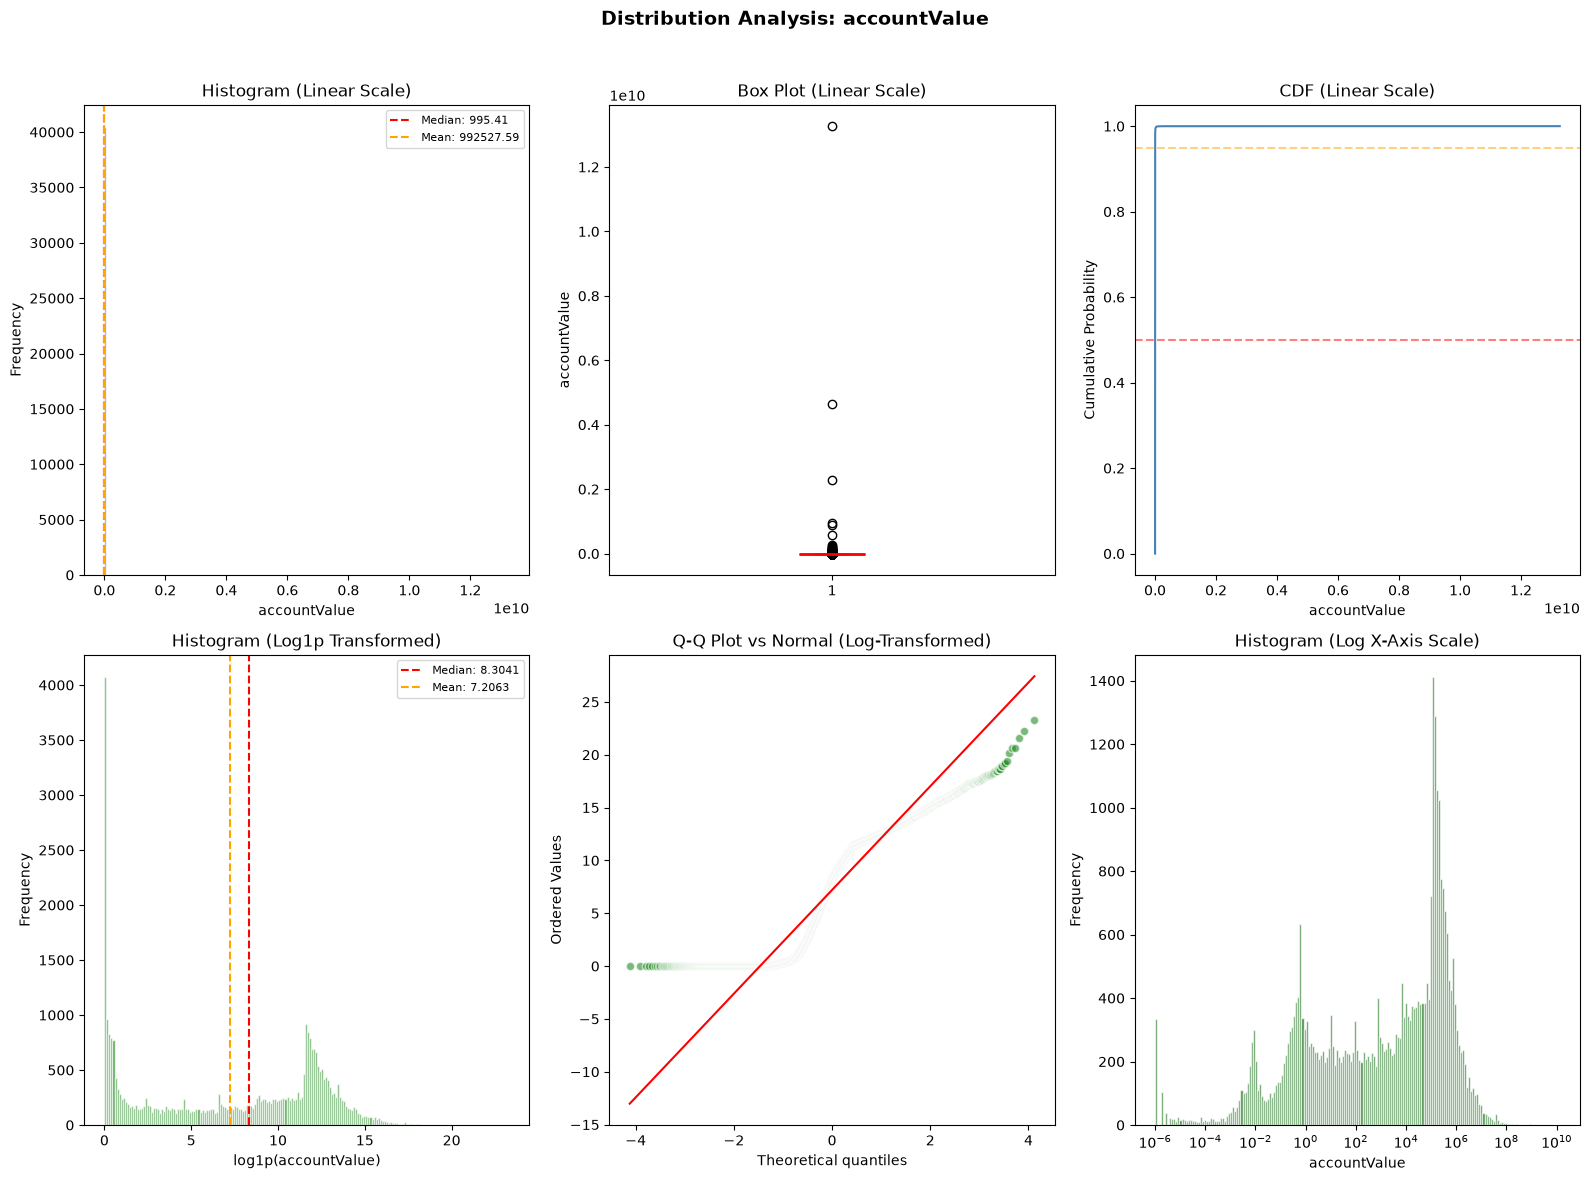


######################################################################
# ANALYZING: all_time_vlm
######################################################################

  DISTRIBUTION ANALYSIS: all_time_vlm

  Count:        40,471
  Mean:         243,797,441.3865
  Std:          6,003,344,283.6336
  Min:          0.0000
  Max:          721,659,936,506.5000

  --- Percentiles ---
  P  1.0:                0.0000
  P  5.0:              999.8650
  P 10.0:          666,948.7400
  P 25.0:       11,235,152.0750
  P 50.0:       20,709,868.4700
  P 75.0:       53,935,198.9850
  P 90.0:       170,341,478.4000
  P 95.0:       376,908,261.4250
  P 99.0:       1,878,084,162.4510
  P 99.5:       3,499,186,256.0766
  P 99.9:       22,369,035,788.2992

  --- Distribution Fitting (Log-Transformed) ---
  Transform:    log1p
  Log Mean:     16.9125
  Log Std:      1.9798
  Log Skew:     -1.2933
  Log Kurtosis: 6.8794

  --- Normality Tests (Log-Transformed) ---
  Shapiro-Wilk: stat=0.9286, p=1.06e-43
  

C:\Users\Administrator\AppData\Local\Temp\1\ipykernel_8152\4292193886.py:90: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data.values, vert=True, patch_artist=True,


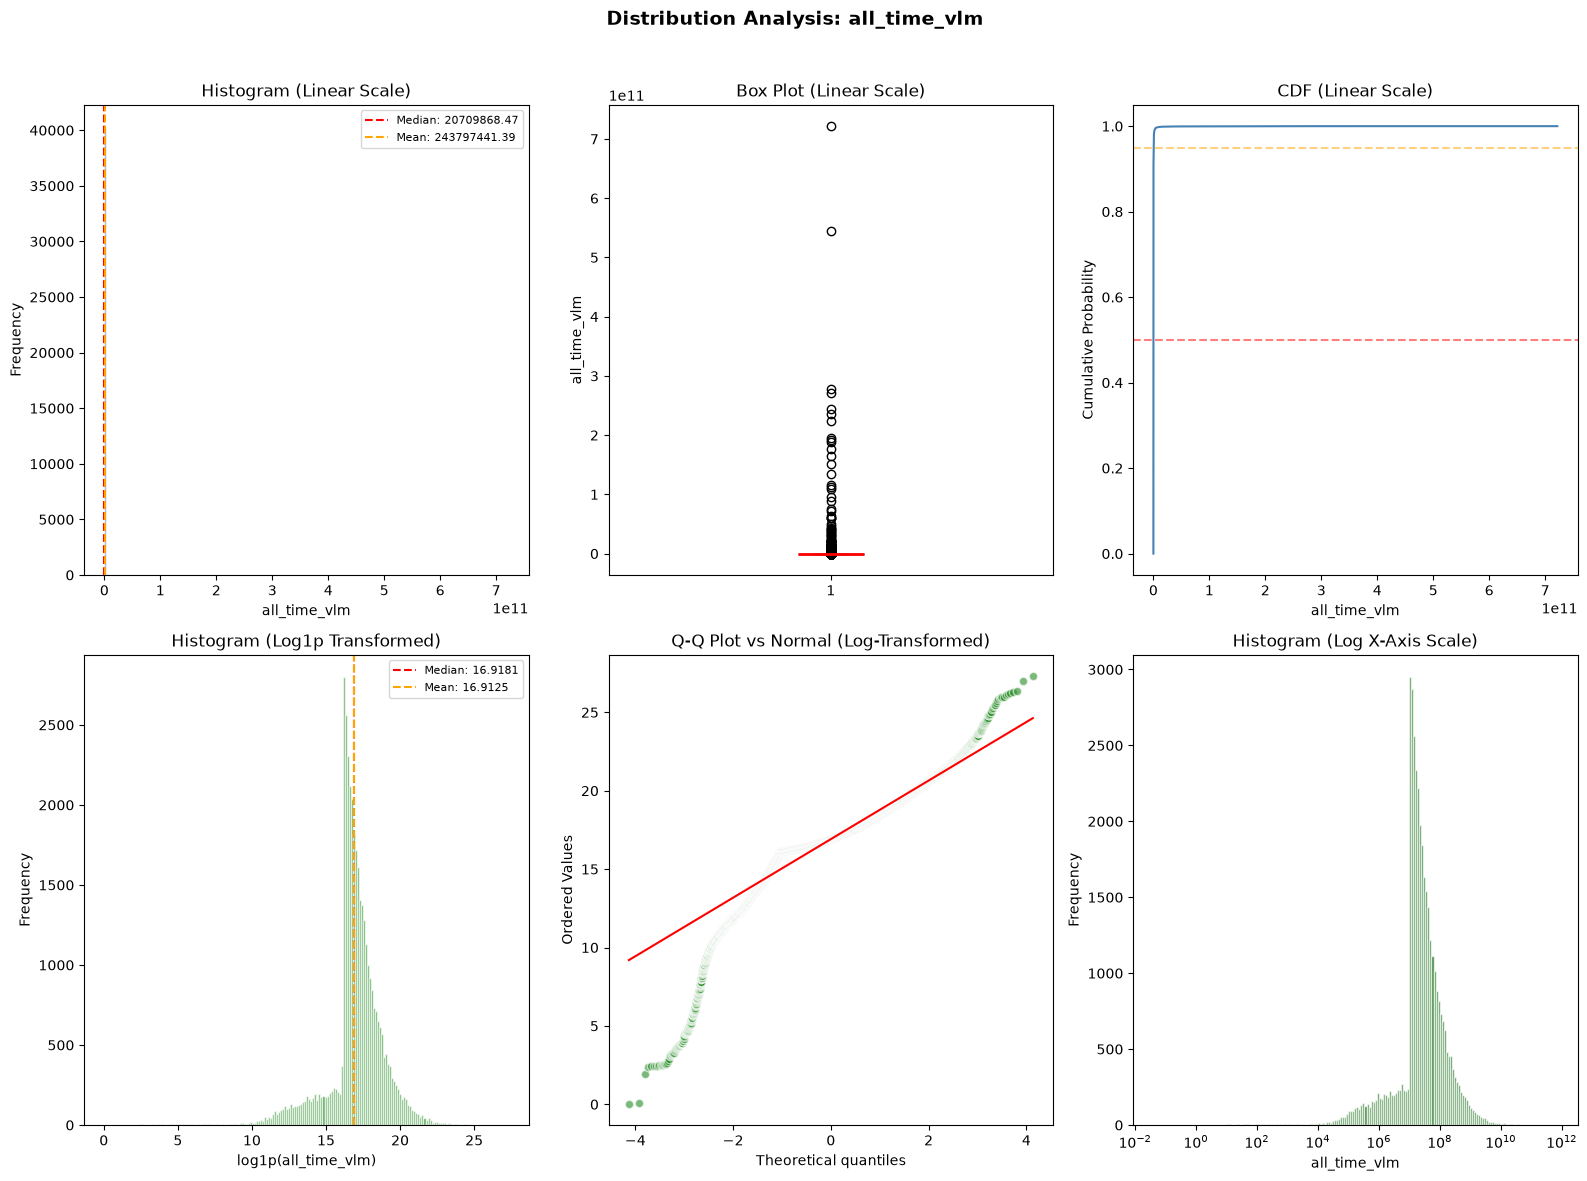


######################################################################
# ANALYZING: day_vlm
######################################################################

  DISTRIBUTION ANALYSIS: day_vlm

  Count:        40,471
  Mean:         116,655.6421
  Std:          3,300,686.4060
  Min:          0.0000
  Max:          338,653,512.7900

  --- Percentiles ---
  P  1.0:                0.0000
  P  5.0:                0.0000
  P 10.0:                0.0000
  P 25.0:                0.0000
  P 50.0:                0.0000
  P 75.0:                0.0000
  P 90.0:            4,345.8800
  P 95.0:           77,991.4050
  P 99.0:        1,194,915.4640
  P 99.5:        2,671,205.8190
  P 99.9:       17,553,102.3209

  --- Distribution Fitting (Log-Transformed) ---
  Transform:    log1p
  Log Mean:     10.6111
  Log Std:      2.6123
  Log Skew:     -0.3843
  Log Kurtosis: 0.7312

  --- Normality Tests (Log-Transformed) ---
  Shapiro-Wilk: stat=0.9885, p=1.49e-19
  KS Test:      stat=0.0371, p=2.70e

C:\Users\Administrator\AppData\Local\Temp\1\ipykernel_8152\4292193886.py:90: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data.values, vert=True, patch_artist=True,


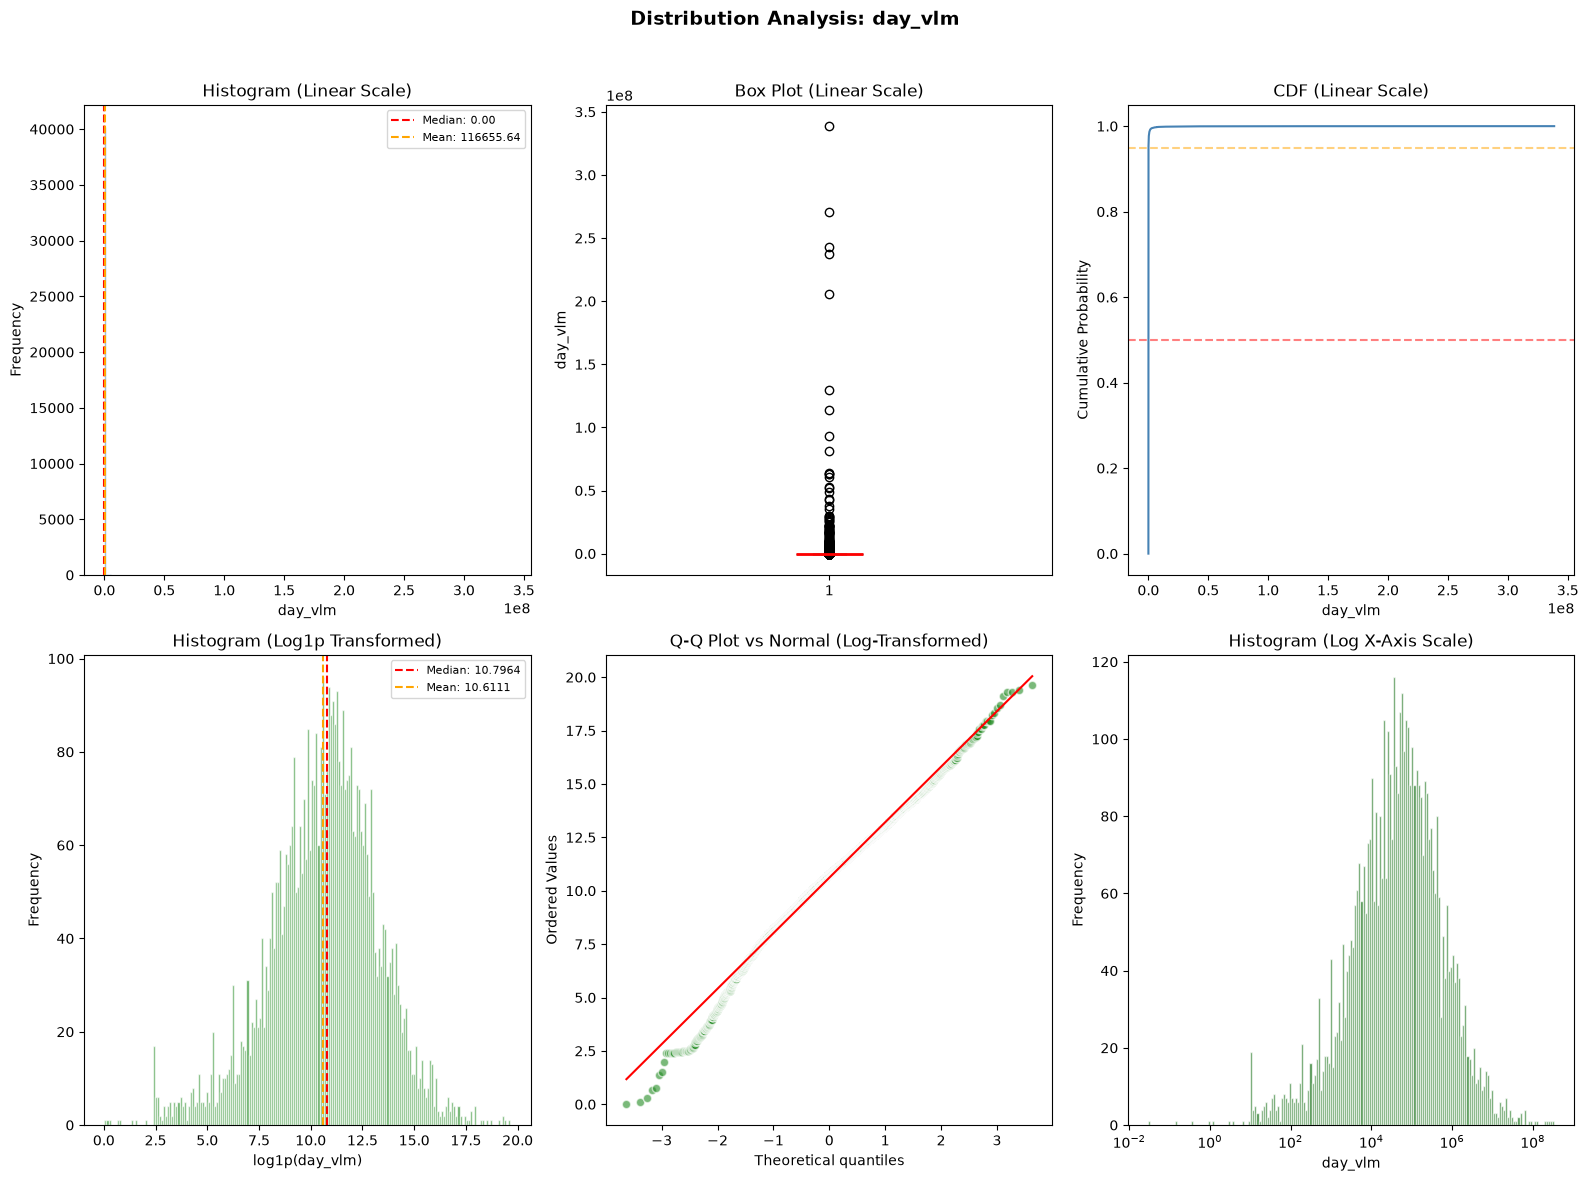


######################################################################
# ANALYZING: week_vlm
######################################################################

  DISTRIBUTION ANALYSIS: week_vlm

  Count:        40,471
  Mean:         2,087,104.7896
  Std:          69,189,355.4808
  Min:          0.0000
  Max:          7,517,306,749.7900

  --- Percentiles ---
  P  1.0:                0.0000
  P  5.0:                0.0000
  P 10.0:                0.0000
  P 25.0:                0.0000
  P 50.0:                0.0000
  P 75.0:            2,776.5050
  P 90.0:          594,758.5800
  P 95.0:        2,267,562.8250
  P 99.0:       19,019,032.6900
  P 99.5:       38,206,650.7205
  P 99.9:       198,263,346.8277

  --- Distribution Fitting (Log-Transformed) ---
  Transform:    log1p
  Log Mean:     12.2002
  Log Std:      2.8802
  Log Skew:     -0.5828
  Log Kurtosis: 0.8853

  --- Normality Tests (Log-Transformed) ---
  Shapiro-Wilk: stat=0.9427, p=2.67e-40
  KS Test:      stat=0.0510,

C:\Users\Administrator\AppData\Local\Temp\1\ipykernel_8152\4292193886.py:90: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data.values, vert=True, patch_artist=True,


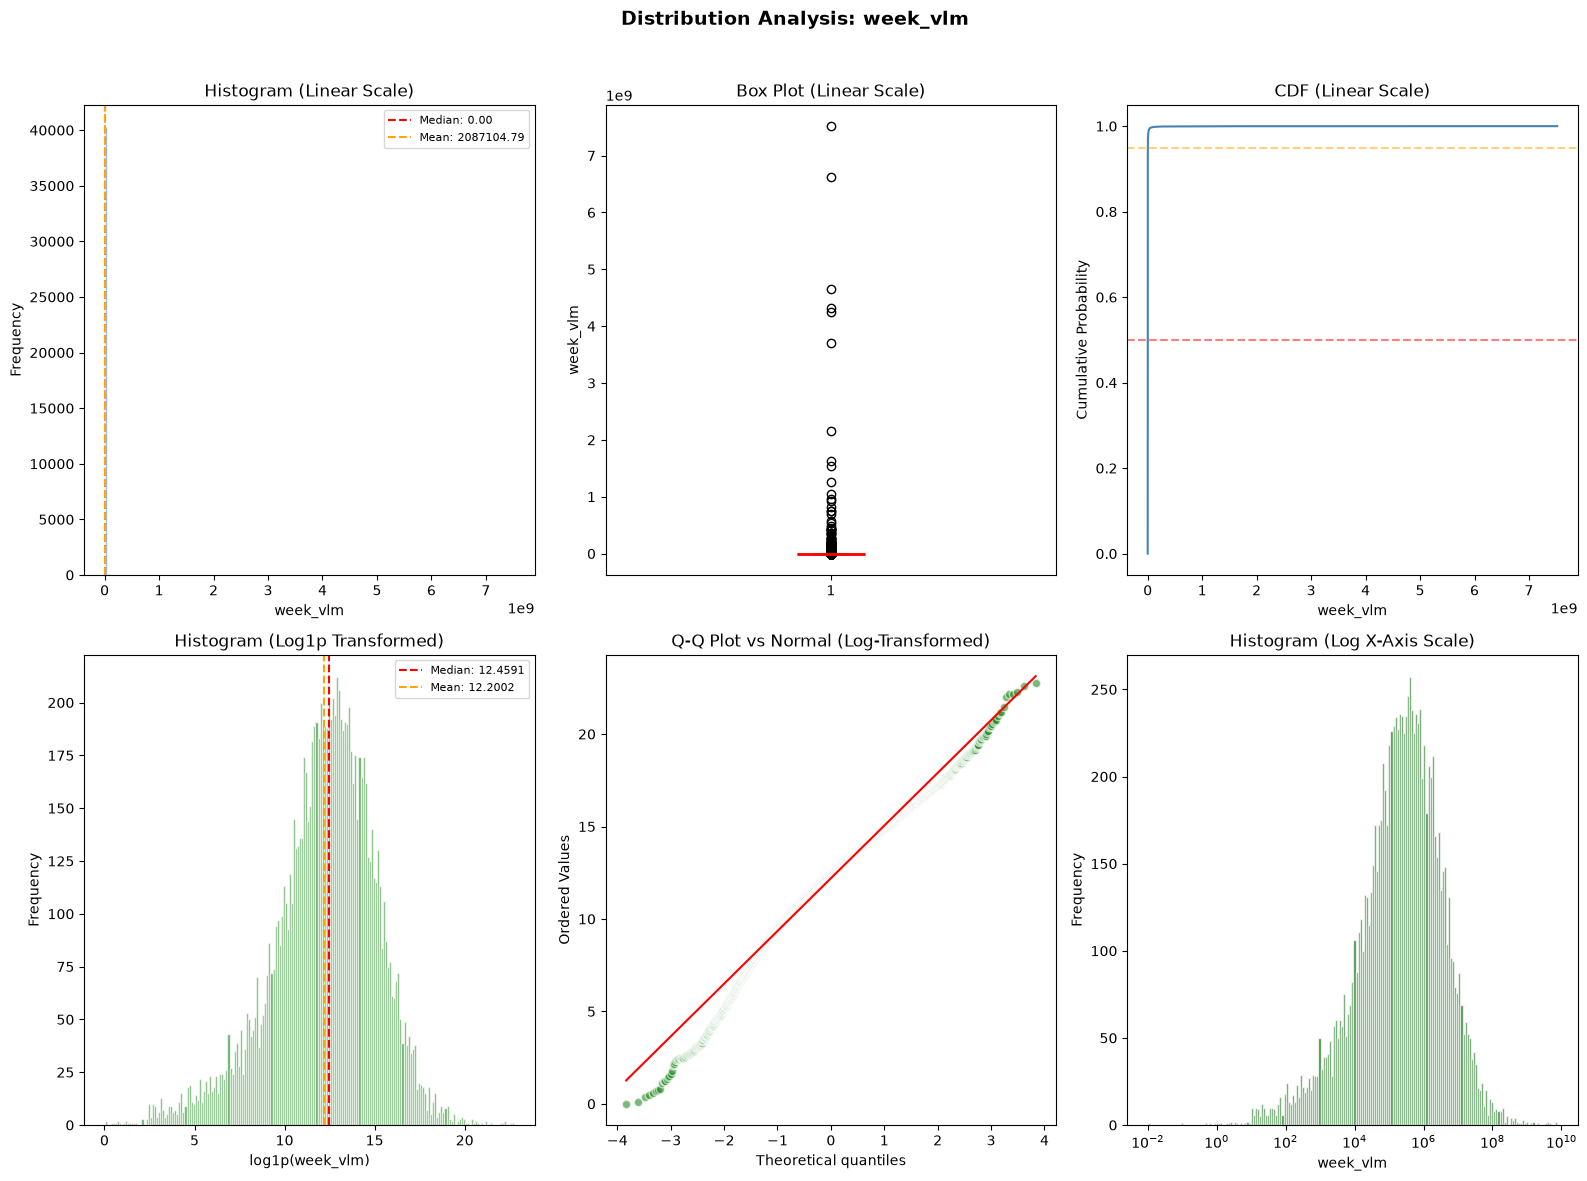


######################################################################
# ANALYZING: month_vlm
######################################################################

  DISTRIBUTION ANALYSIS: month_vlm

  Count:        40,471
  Mean:         10,045,773.9933
  Std:          307,722,693.5538
  Min:          0.0000
  Max:          33,943,399,011.0300

  --- Percentiles ---
  P  1.0:                0.0000
  P  5.0:                0.0000
  P 10.0:                0.0000
  P 25.0:                0.0000
  P 50.0:                0.0000
  P 75.0:          338,354.4700
  P 90.0:        4,757,671.5800
  P 95.0:       14,101,579.2200
  P 99.0:       81,389,639.5680
  P 99.5:       181,024,895.1525
  P 99.9:       980,866,530.2447

  --- Distribution Fitting (Log-Transformed) ---
  Transform:    log1p
  Log Mean:     13.0328
  Log Std:      3.3093
  Log Skew:     -0.8058
  Log Kurtosis: 0.8809

  --- Normality Tests (Log-Transformed) ---
  Shapiro-Wilk: stat=0.8837, p=8.71e-52
  KS Test:      stat=0

C:\Users\Administrator\AppData\Local\Temp\1\ipykernel_8152\4292193886.py:90: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data.values, vert=True, patch_artist=True,


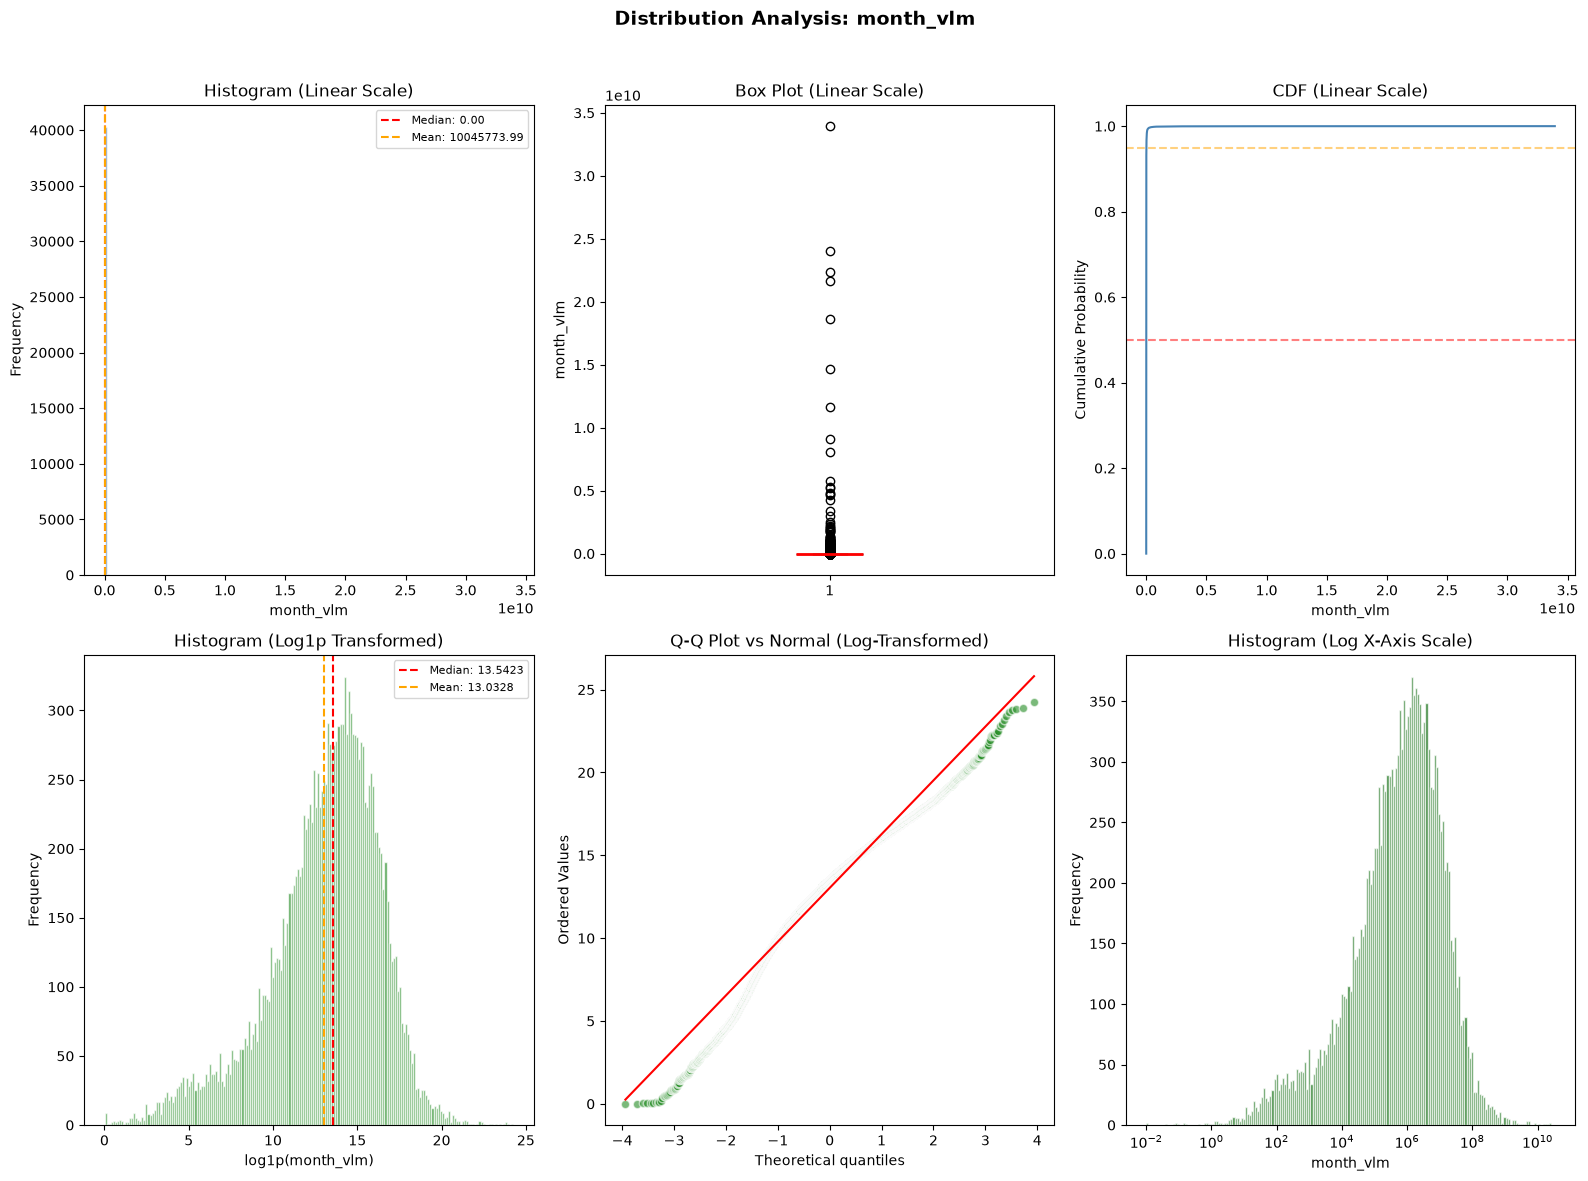


######################################################################
# ANALYZING: all_time_pnl
######################################################################

  DISTRIBUTION ANALYSIS: all_time_pnl

  Count:        40,471
  Mean:         319,901.0079
  Std:          4,558,188.0824
  Min:          -128,874,183.7300
  Max:          445,047,889.9056

  --- Percentiles ---
  P  1.0:       -2,024,300.2503
  P  5.0:         -370,631.2300
  P 10.0:         -160,632.0000
  P 25.0:          -35,570.1359
  P 50.0:             -250.6874
  P 75.0:           79,989.6545
  P 90.0:          451,851.6081
  P 95.0:        1,195,862.3033
  P 99.0:        7,455,044.0212
  P 99.5:       13,877,283.2127
  P 99.9:       50,468,690.5928

  --- Distribution Fitting (Log-Transformed) ---
  Transform:    signed log
  Log Mean:     0.0132
  Log Std:      10.9818
  Log Skew:     0.0910
  Log Kurtosis: -1.8338

  --- Normality Tests (Log-Transformed) ---
  Shapiro-Wilk: stat=0.7974, p=7.77e-62
  KS Test:

C:\Users\Administrator\AppData\Local\Temp\1\ipykernel_8152\4292193886.py:90: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data.values, vert=True, patch_artist=True,


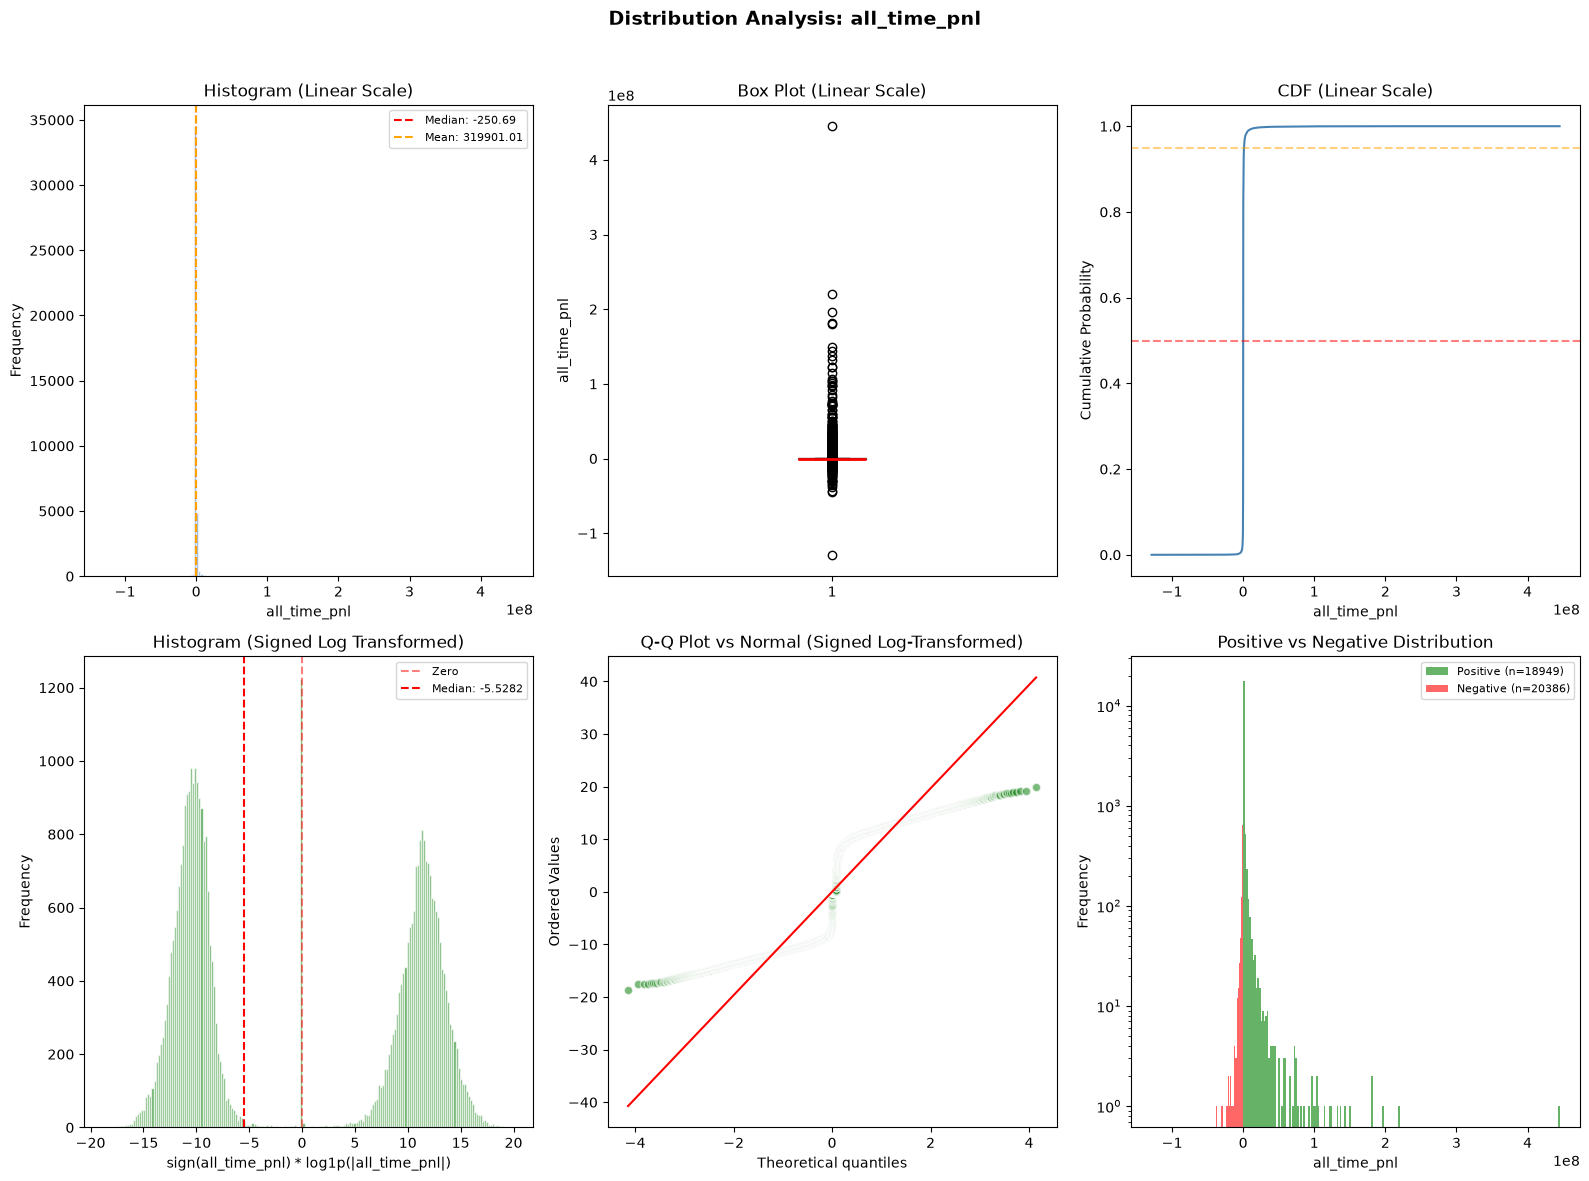


######################################################################
# ANALYZING: day_pnl
######################################################################

  DISTRIBUTION ANALYSIS: day_pnl

  Count:        40,471
  Mean:         4,471.3344
  Std:          136,315.6728
  Min:          -1,275,239.4067
  Max:          23,475,994.1110

  --- Percentiles ---
  P  1.0:           -7,222.9195
  P  5.0:             -300.3831
  P 10.0:                0.0000
  P 25.0:                0.0000
  P 50.0:                0.0019
  P 75.0:              216.3179
  P 90.0:            3,972.8722
  P 95.0:           10,623.9718
  P 99.0:           76,690.3866
  P 99.5:          137,854.1502
  P 99.9:          563,899.2230

  --- Distribution Fitting (Log-Transformed) ---
  Transform:    signed log
  Log Mean:     1.8365
  Log Std:      4.3428
  Log Skew:     0.1799
  Log Kurtosis: 0.1192

  --- Normality Tests (Log-Transformed) ---
  Shapiro-Wilk: stat=0.9422, p=1.96e-40
  KS Test:      stat=0.2748, 

C:\Users\Administrator\AppData\Local\Temp\1\ipykernel_8152\4292193886.py:90: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data.values, vert=True, patch_artist=True,


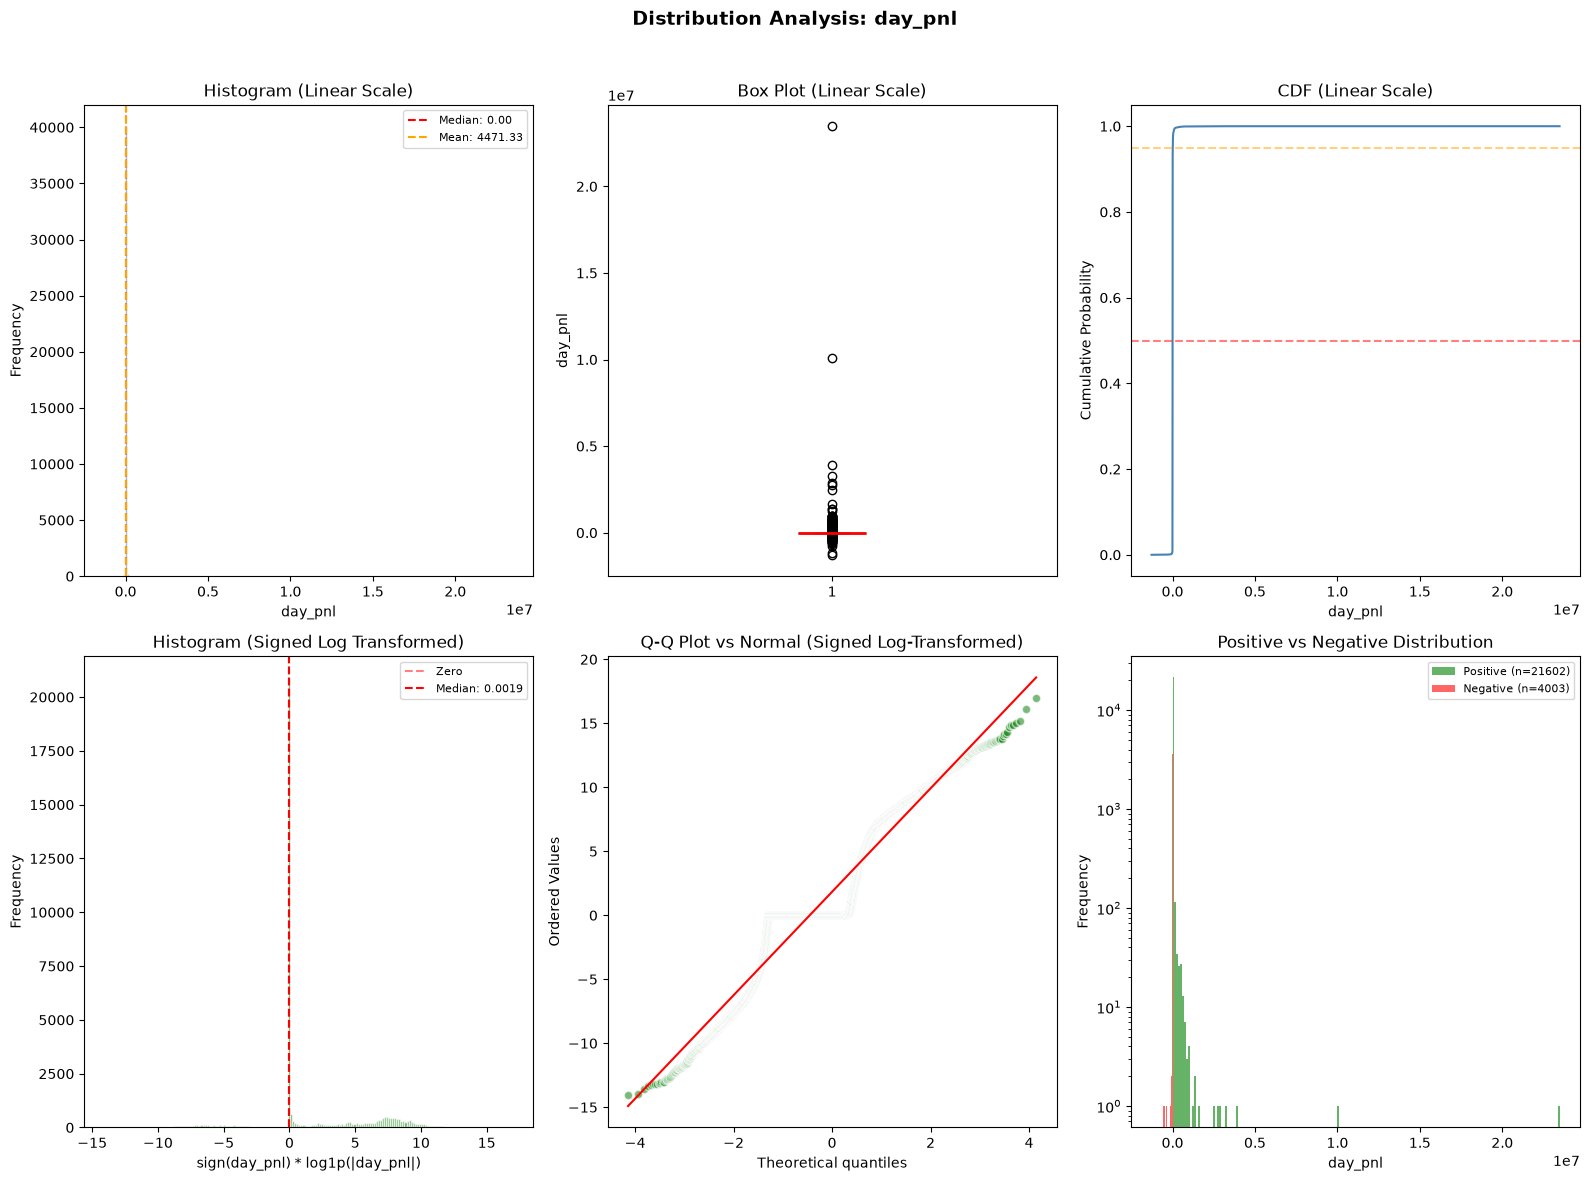


######################################################################
# ANALYZING: week_pnl
######################################################################

  DISTRIBUTION ANALYSIS: week_pnl

  Count:        40,471
  Mean:         7,281.2102
  Std:          1,270,592.9328
  Min:          -3,166,603.7784
  Max:          253,899,315.4942

  --- Percentiles ---
  P  1.0:          -58,489.9387
  P  5.0:           -5,224.9180
  P 10.0:             -736.5670
  P 25.0:                0.0000
  P 50.0:                0.0000
  P 75.0:                0.0000
  P 90.0:              997.6517
  P 95.0:            5,869.9375
  P 99.0:           58,613.1550
  P 99.5:          133,807.2049
  P 99.9:          612,008.7083

  --- Distribution Fitting (Log-Transformed) ---
  Transform:    signed log
  Log Mean:     0.1083
  Log Std:      4.4432
  Log Skew:     -0.0009
  Log Kurtosis: 1.1144

  --- Normality Tests (Log-Transformed) ---
  Shapiro-Wilk: stat=0.8816, p=4.23e-52
  KS Test:      stat=0.

C:\Users\Administrator\AppData\Local\Temp\1\ipykernel_8152\4292193886.py:90: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data.values, vert=True, patch_artist=True,


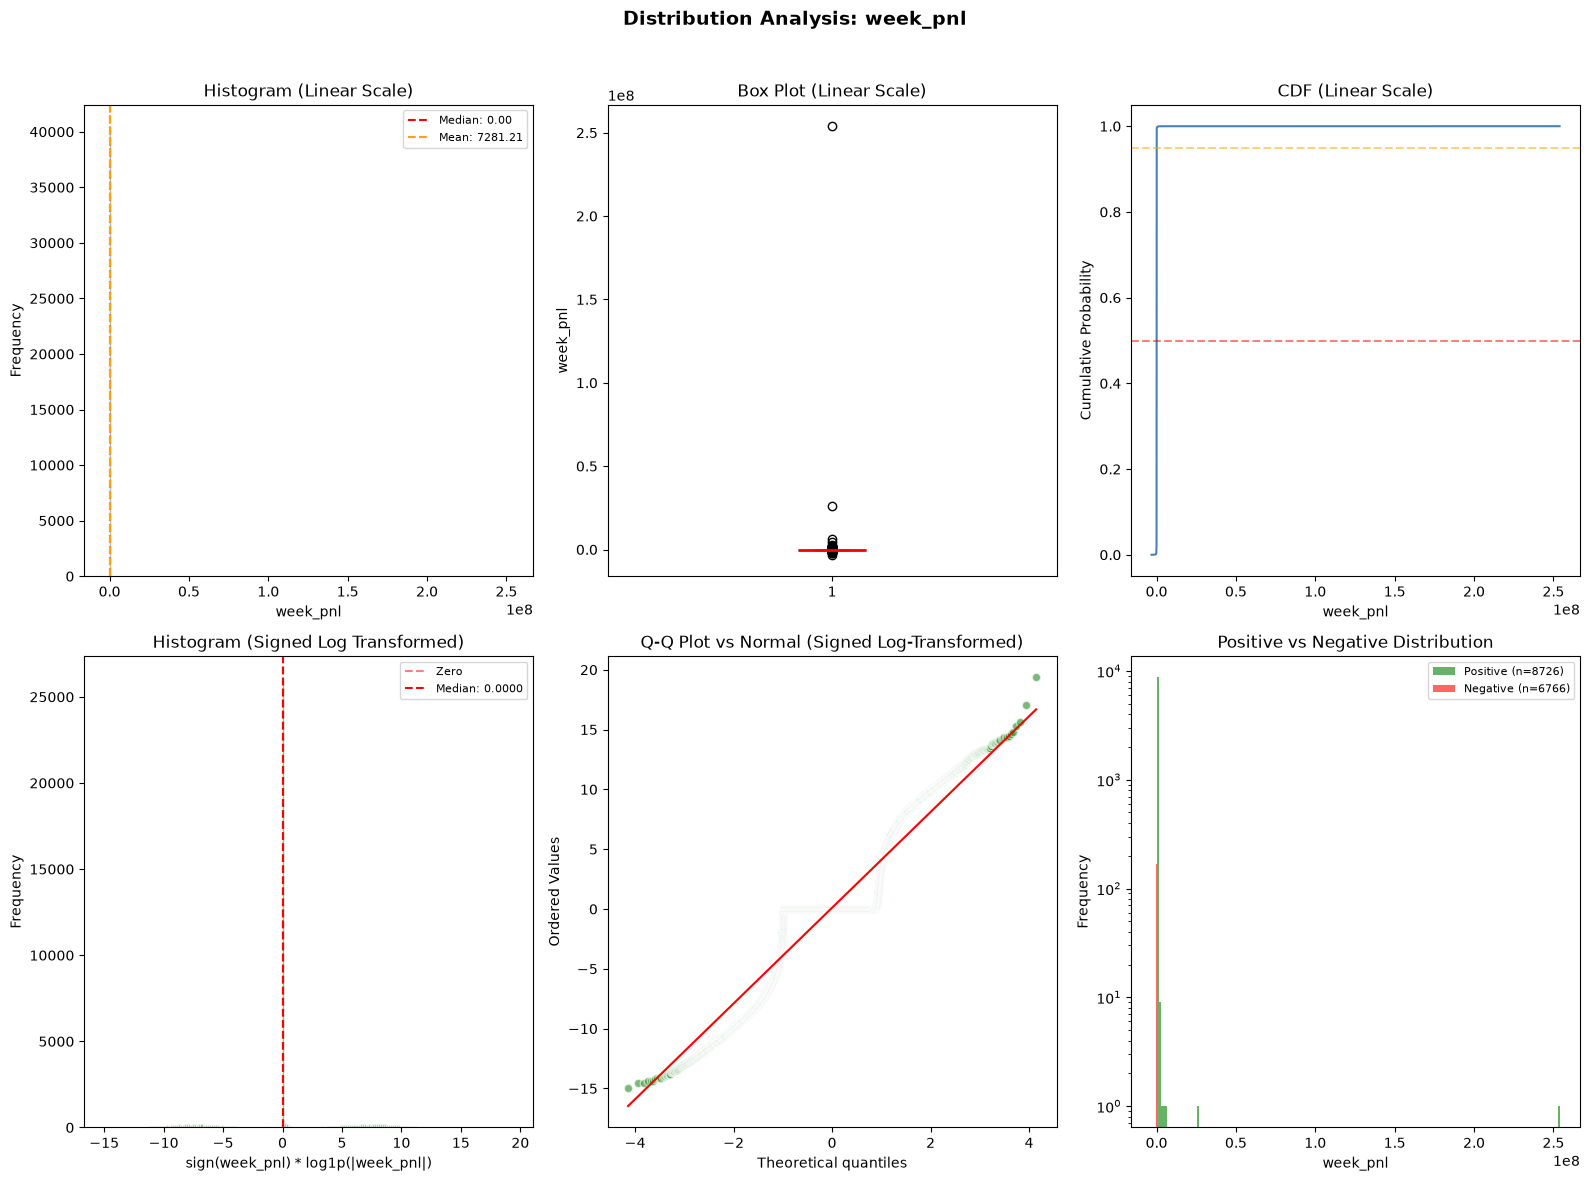


######################################################################
# ANALYZING: month_pnl
######################################################################

  DISTRIBUTION ANALYSIS: month_pnl

  Count:        40,471
  Mean:         46,374.1372
  Std:          1,322,613.4260
  Min:          -8,489,198.2229
  Max:          160,859,686.1910

  --- Percentiles ---
  P  1.0:         -146,497.6411
  P  5.0:          -14,305.3598
  P 10.0:           -2,364.5601
  P 25.0:                0.0000
  P 50.0:                0.0160
  P 75.0:            2,996.5300
  P 90.0:           35,886.5203
  P 95.0:          104,747.5531
  P 99.0:          840,077.2144
  P 99.5:        1,541,412.2670
  P 99.9:        6,032,637.8788

  --- Distribution Fitting (Log-Transformed) ---
  Transform:    signed log
  Log Mean:     1.8780
  Log Std:      6.3978
  Log Skew:     -0.1096
  Log Kurtosis: -0.5757

  --- Normality Tests (Log-Transformed) ---
  Shapiro-Wilk: stat=0.7980, p=8.92e-62
  KS Test:      sta

C:\Users\Administrator\AppData\Local\Temp\1\ipykernel_8152\4292193886.py:90: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data.values, vert=True, patch_artist=True,


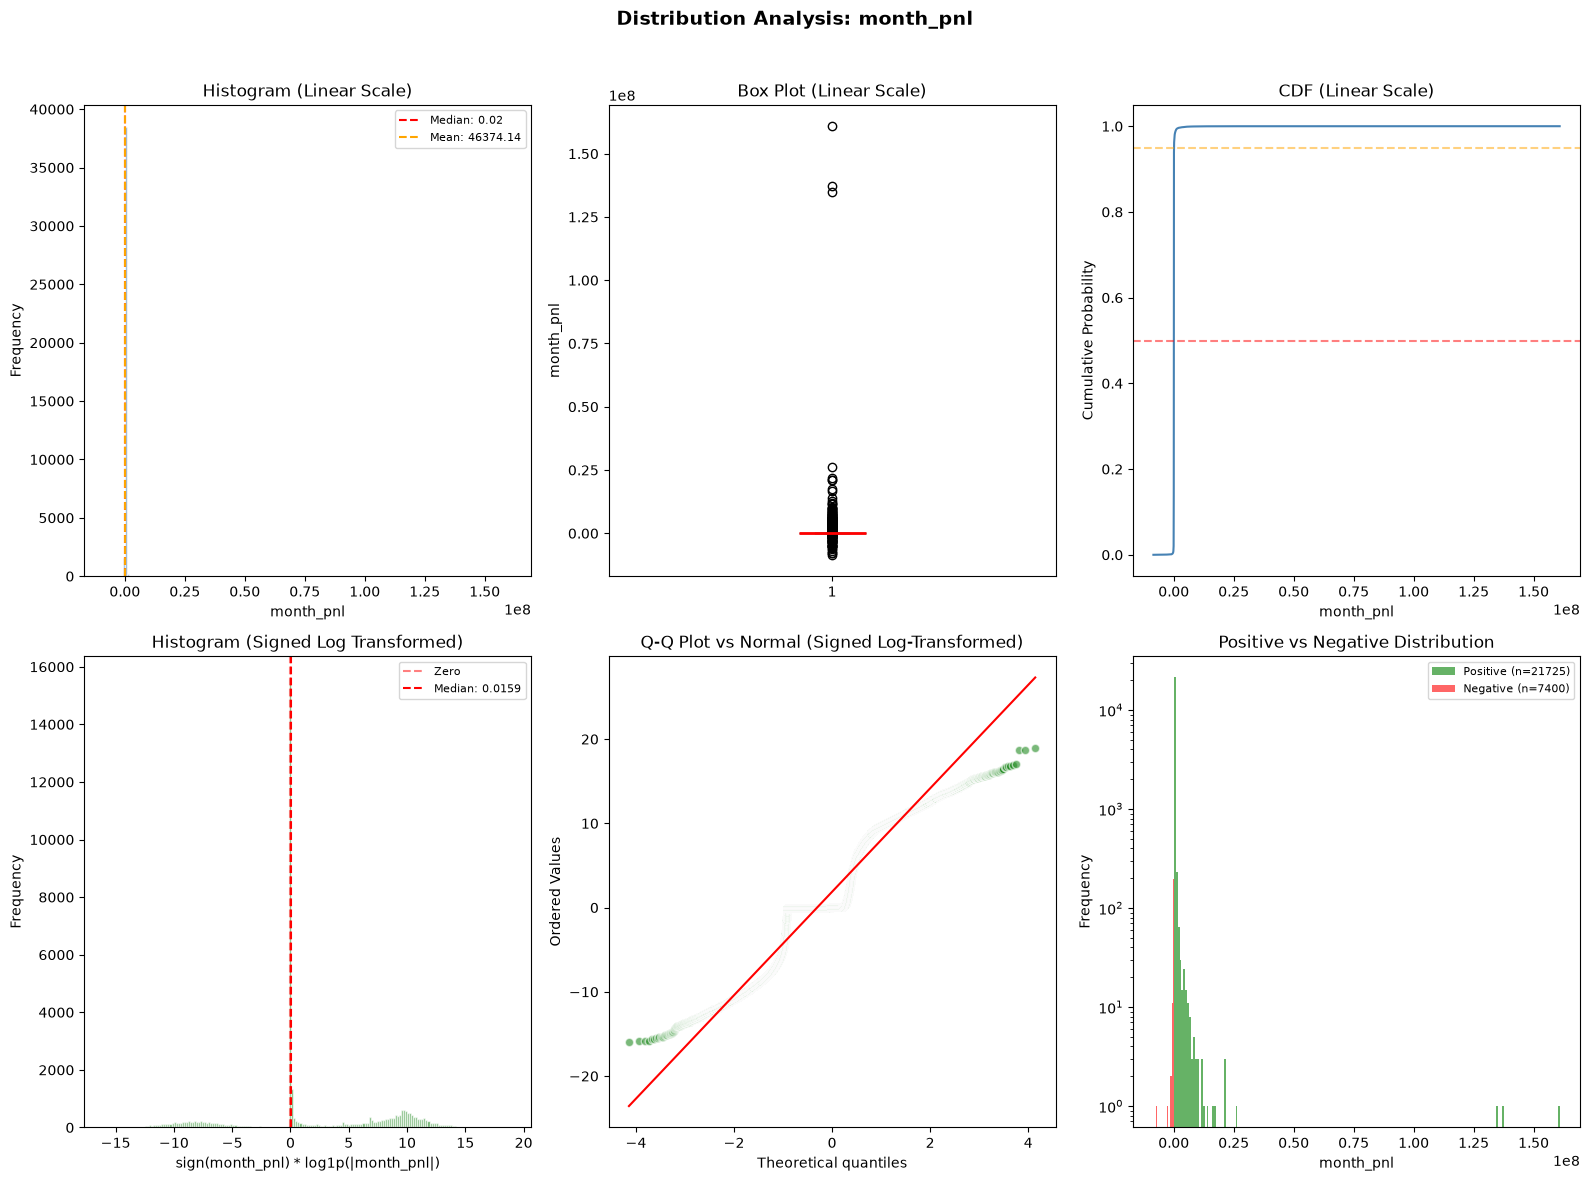


######################################################################
# ANALYZING: all_time_roi
######################################################################

  DISTRIBUTION ANALYSIS: all_time_roi

  Count:        40,471
  Mean:         44.9615
  Std:          1,676.7256
  Min:          -1.0000
  Max:          168,656.5092

  --- Percentiles ---
  P  1.0:               -1.0000
  P  5.0:               -0.9993
  P 10.0:               -0.9891
  P 25.0:               -0.7772
  P 50.0:               -0.0043
  P 75.0:                0.7064
  P 90.0:                3.7219
  P 95.0:               12.3748
  P 99.0:              149.5137
  P 99.5:              523.8802
  P 99.9:            7,871.6479

  --- Distribution Fitting (Log-Transformed) ---
  Transform:    signed log
  Log Mean:     0.2507
  Log Std:      1.1915
  Log Skew:     2.8335
  Log Kurtosis: 12.0624

  --- Normality Tests (Log-Transformed) ---
  Shapiro-Wilk: stat=0.7377, p=8.10e-67
  KS Test:      stat=0.2141, p=0.0

C:\Users\Administrator\AppData\Local\Temp\1\ipykernel_8152\4292193886.py:90: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data.values, vert=True, patch_artist=True,


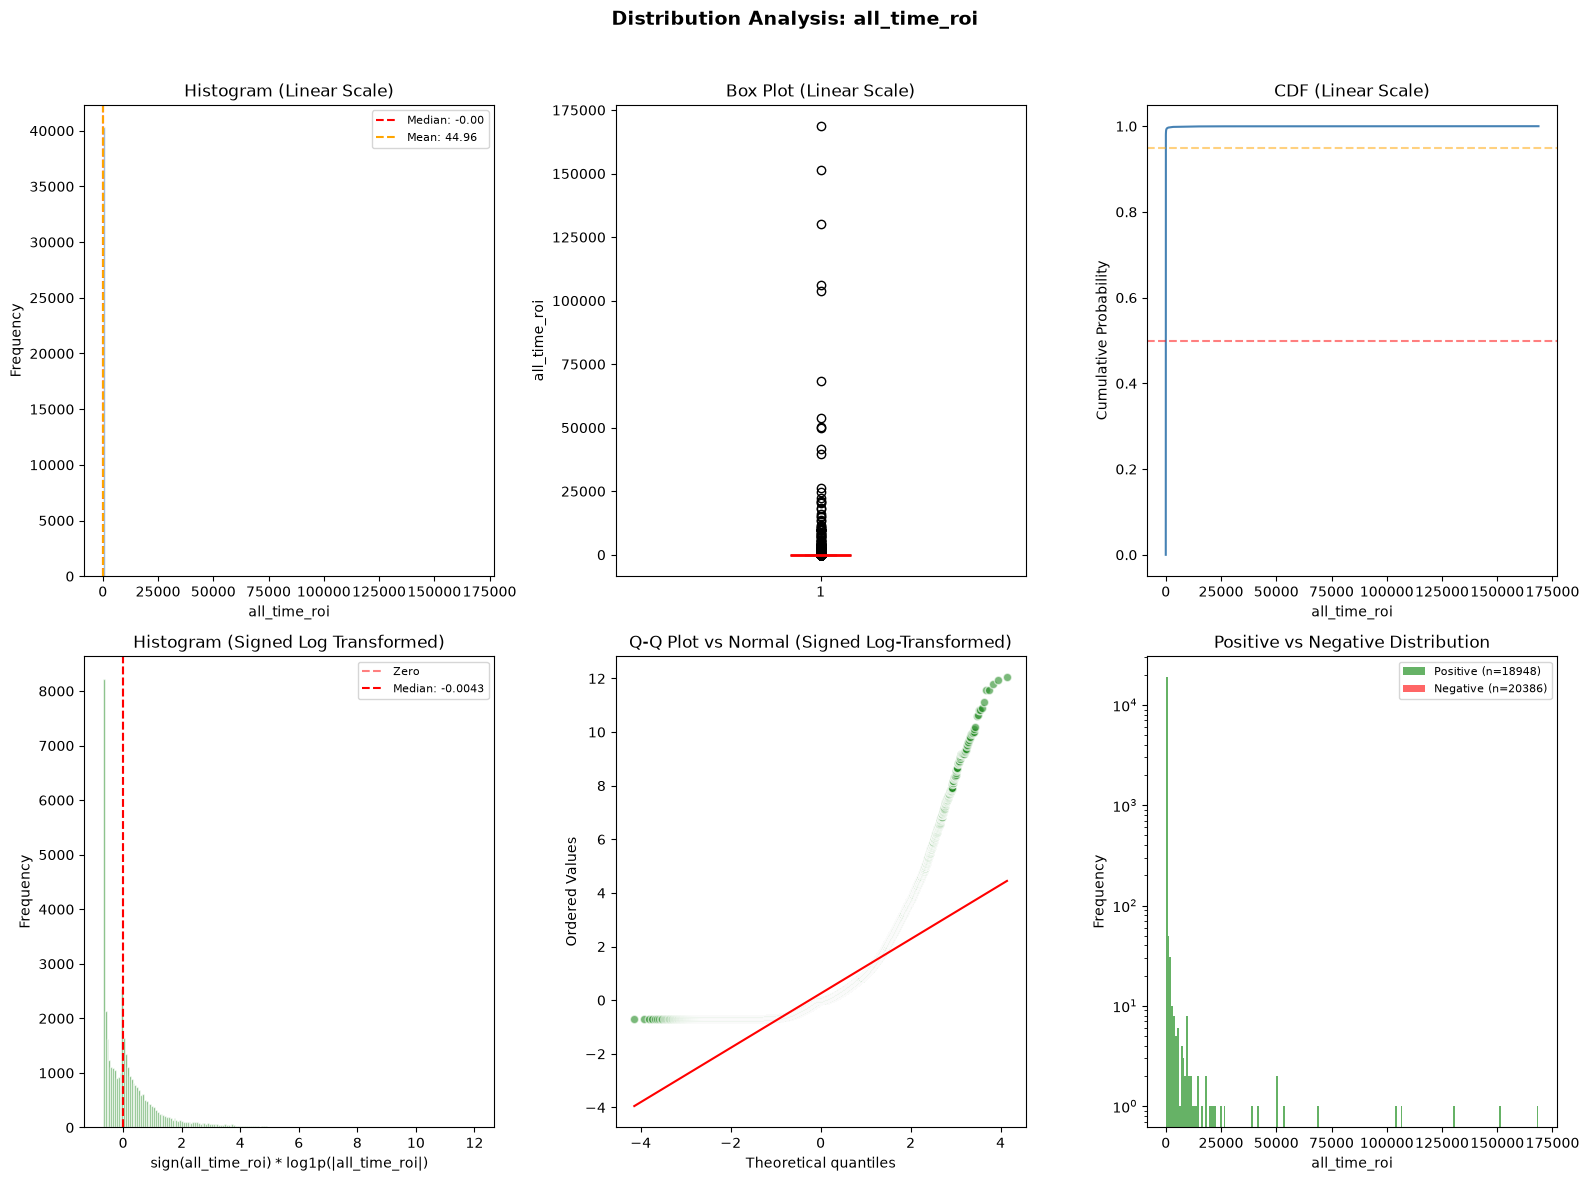


######################################################################
# ANALYZING: day_roi
######################################################################

  DISTRIBUTION ANALYSIS: day_roi

  Count:        40,471
  Mean:         0.0035
  Std:          0.0557
  Min:          -1.0000
  Max:          2.9950

  --- Percentiles ---
  P  1.0:               -0.1167
  P  5.0:               -0.0114
  P 10.0:                0.0000
  P 25.0:                0.0000
  P 50.0:                0.0000
  P 75.0:                0.0081
  P 90.0:                0.0145
  P 95.0:                0.0272
  P 99.0:                0.1299
  P 99.5:                0.2314
  P 99.9:                0.5555

  --- Distribution Fitting (Log-Transformed) ---
  Transform:    signed log
  Log Mean:     0.0035
  Log Std:      0.0438
  Log Skew:     0.1820
  Log Kurtosis: 124.0889

  --- Normality Tests (Log-Transformed) ---
  Shapiro-Wilk: stat=0.5932, p=9.38e-76
  KS Test:      stat=0.3736, p=0.00e+00


C:\Users\Administrator\AppData\Local\Temp\1\ipykernel_8152\4292193886.py:90: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data.values, vert=True, patch_artist=True,


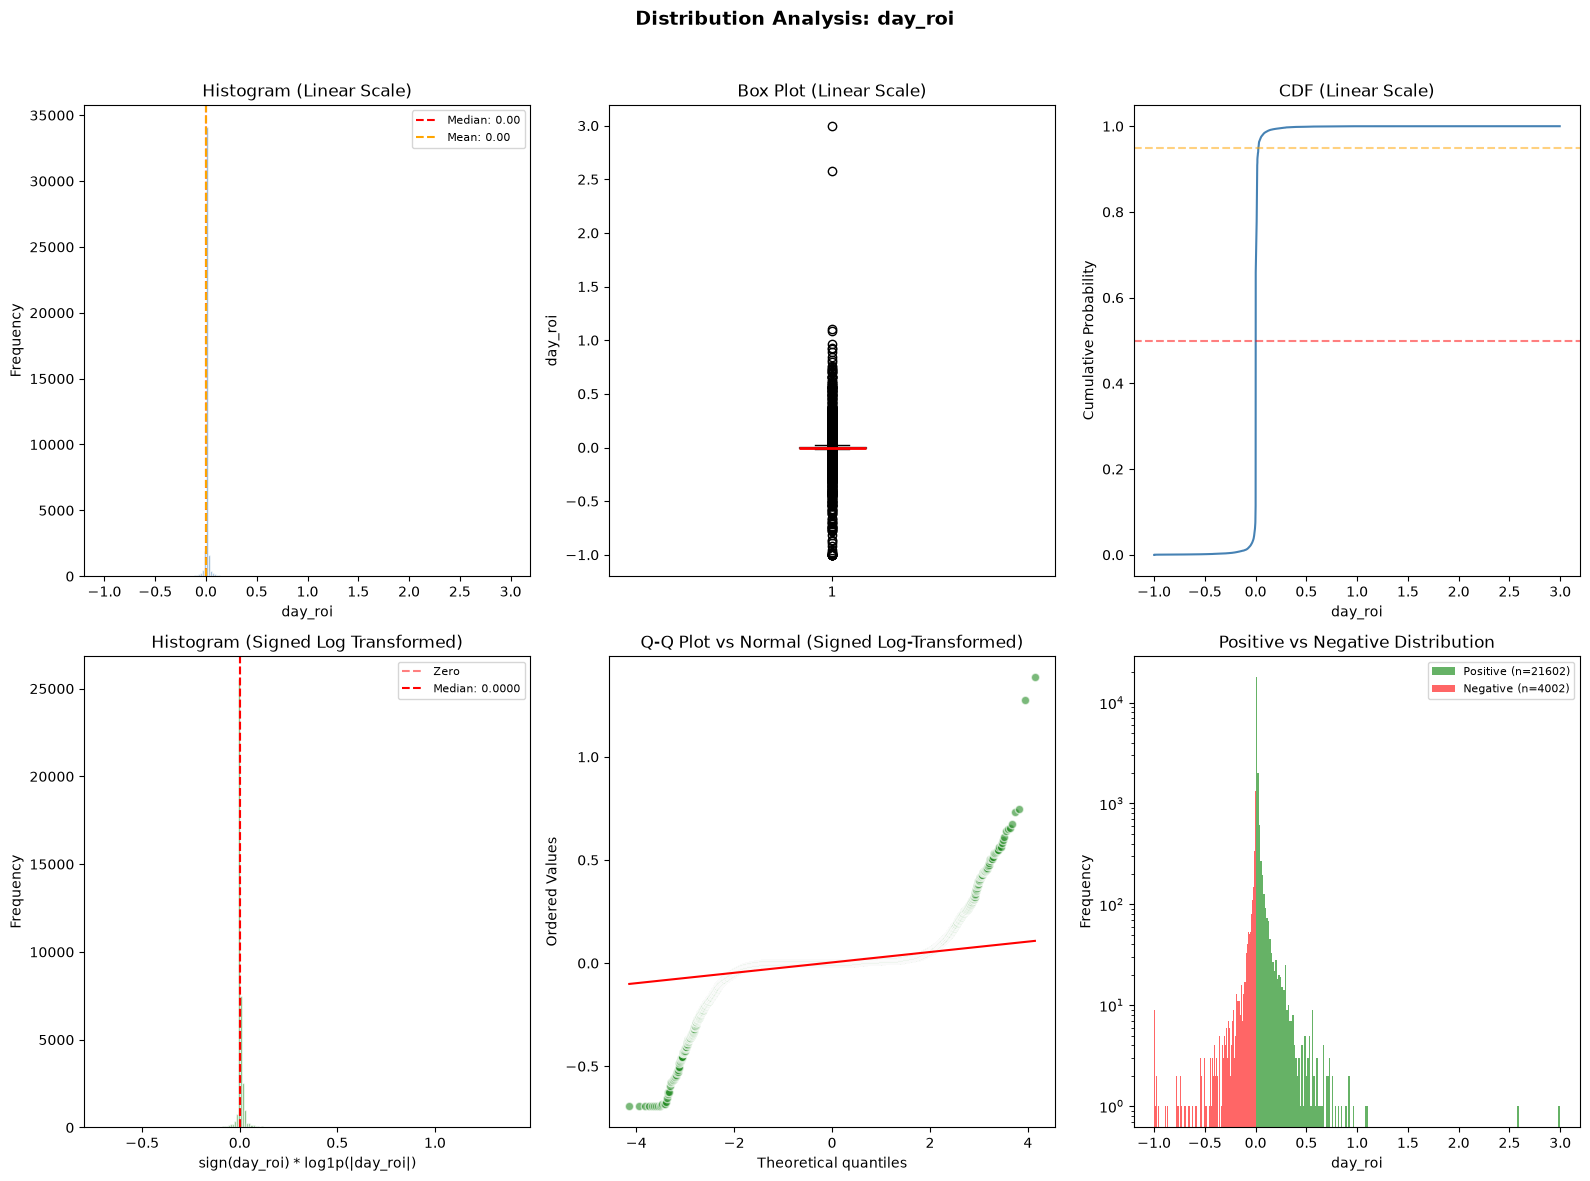


######################################################################
# ANALYZING: week_roi
######################################################################

  DISTRIBUTION ANALYSIS: week_roi

  Count:        40,471
  Mean:         0.0112
  Std:          1.8998
  Min:          -1.0000
  Max:          355.6287

  --- Percentiles ---
  P  1.0:               -0.6656
  P  5.0:               -0.2132
  P 10.0:               -0.0683
  P 25.0:                0.0000
  P 50.0:                0.0000
  P 75.0:                0.0000
  P 90.0:                0.0340
  P 95.0:                0.1191
  P 99.0:                0.4656
  P 99.5:                0.6747
  P 99.9:                2.3537

  --- Distribution Fitting (Log-Transformed) ---
  Transform:    signed log
  Log Mean:     -0.0068
  Log Std:      0.1433
  Log Skew:     7.1013
  Log Kurtosis: 206.9303

  --- Normality Tests (Log-Transformed) ---
  Shapiro-Wilk: stat=0.7118, p=1.10e-68
  KS Test:      stat=0.3570, p=0.00e+00


C:\Users\Administrator\AppData\Local\Temp\1\ipykernel_8152\4292193886.py:90: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data.values, vert=True, patch_artist=True,


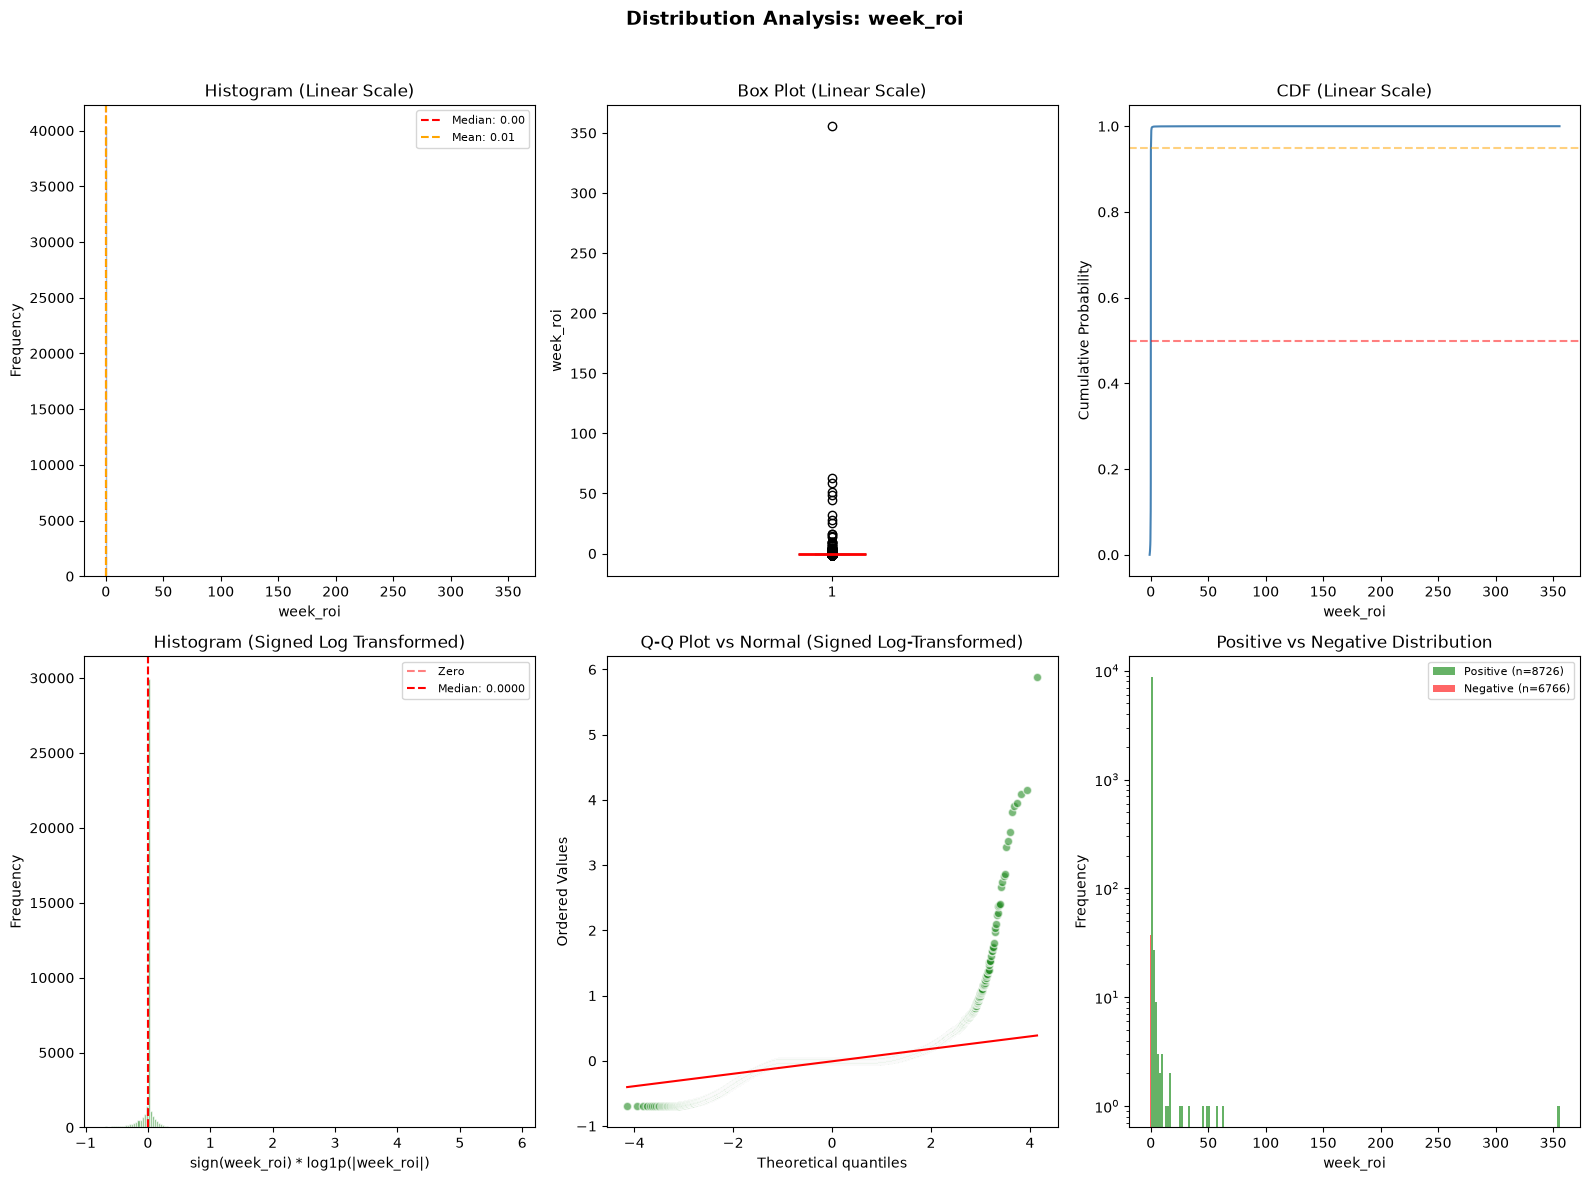


######################################################################
# ANALYZING: month_roi
######################################################################

  DISTRIBUTION ANALYSIS: month_roi

  Count:        40,471
  Mean:         0.0310
  Std:          2.1286
  Min:          -1.0000
  Max:          390.0087

  --- Percentiles ---
  P  1.0:               -0.9446
  P  5.0:               -0.5166
  P 10.0:               -0.1752
  P 25.0:                0.0000
  P 50.0:                0.0001
  P 75.0:                0.0816
  P 90.0:                0.1552
  P 95.0:                0.2483
  P 99.0:                0.9190
  P 99.5:                1.4364
  P 99.9:                4.0784

  --- Distribution Fitting (Log-Transformed) ---
  Transform:    signed log
  Log Mean:     0.0092
  Log Std:      0.2162
  Log Skew:     2.3695
  Log Kurtosis: 48.8513

  --- Normality Tests (Log-Transformed) ---
  Shapiro-Wilk: stat=0.9415, p=1.25e-40
  KS Test:      stat=0.3046, p=0.00e+00


C:\Users\Administrator\AppData\Local\Temp\1\ipykernel_8152\4292193886.py:90: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data.values, vert=True, patch_artist=True,


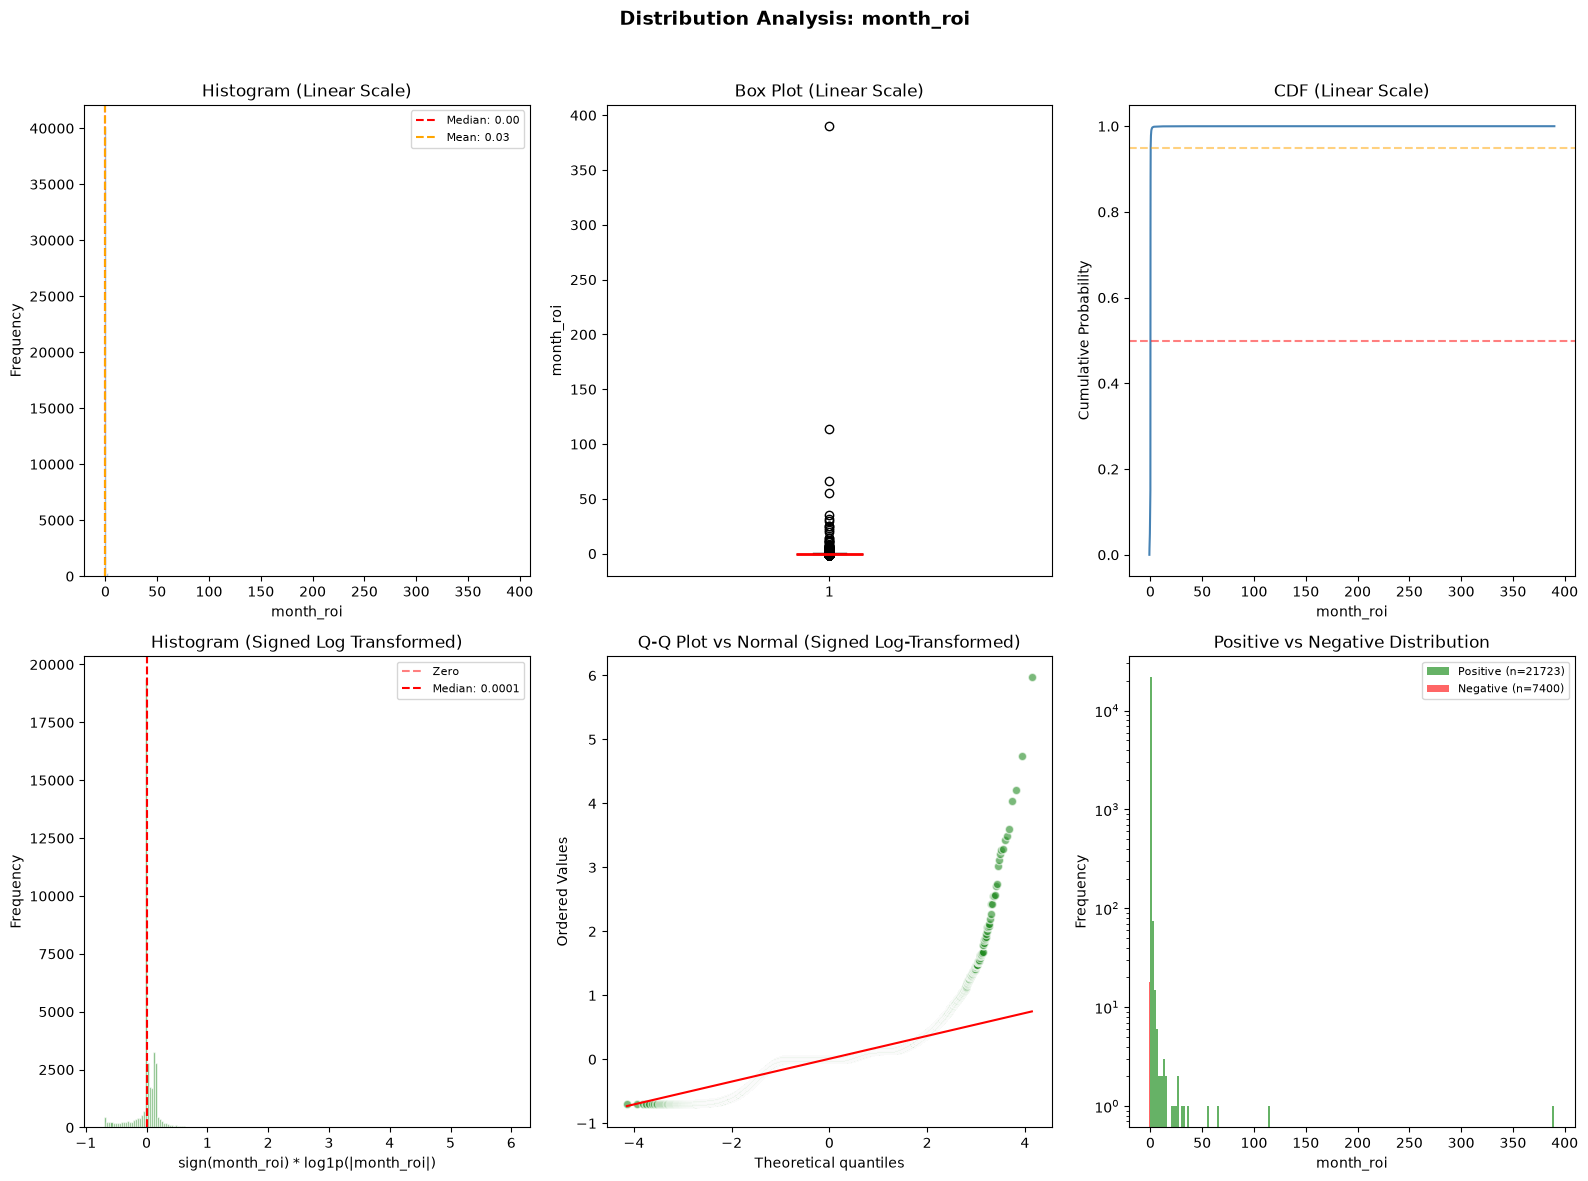

{'accountValue': 0        6.270570e+07
 1        2.624382e+07
 2        7.772168e+07
 3        1.554402e+07
 4        1.333345e+07
              ...     
 40466    1.760590e-01
 40467    9.317135e+03
 40468    1.456281e+00
 40469    3.476694e+00
 40470    8.270916e+01
 Name: accountValue, Length: 40471, dtype: float64,
 'all_time_vlm': 0        1.165343e+11
 1        8.961455e+10
 2        5.443332e+11
 3        1.949478e+11
 4        2.237785e+11
              ...     
 40466    1.658467e+08
 40467    4.055890e+07
 40468    1.228684e+07
 40469    2.298225e+07
 40470    1.518958e+08
 Name: all_time_vlm, Length: 40471, dtype: float64,
 'day_vlm': 0        3.386535e+08
 1        2.053456e+08
 2        2.432118e+08
 3        2.703431e+08
 4        1.141188e+08
              ...     
 40466    0.000000e+00
 40467    0.000000e+00
 40468    0.000000e+00
 40469    0.000000e+00
 40470    0.000000e+00
 Name: day_vlm, Length: 40471, dtype: float64,
 'week_vlm': 0        6.628567e+09
 1        7.

In [7]:
analyzeAllMetrics(leaderboard)